# EDA regional — Análisis A (producción por piso ecológico)

Exploración **descriptiva** de `dataset_regional.csv` (agregado región × piso × mes, cultivos Pareto-80 sumados).

**Objetivos (alineados al paper):**
1. Caracterizar volumen y estacionalidad productiva por unidad territorial.
2. Describir perfiles climáticos por piso ecológico.
3. Explorar co-movimientos clima–producción (Pearson, sin inferencia causal).
4. Documentar eventos extremos: sequía Puno 2022 y El Niño costero 2023–2024.

**Limitaciones explícitas:**
- Correlación ≠ causalidad; sin desestacionalización ni corrección Benjamini–Hochberg.
- Cultivos del mismo (región, piso, distrito) comparten clima idéntico.
- Producción en toneladas (volumen), no rendimiento t/ha.

**Unidades:** `radiacion_solar` MJ/m²/día; `precipitacion` mm/día; `humedad_suelo` índice 0–1.

**Downstream:** hallazgos regionales contextualizan `05_eda_por_cultivo.ipynb` y `06_clustering_cultivos.ipynb`.

In [2]:
# =============================================================================
# CELDA 1 — Configuración inicial y carga de dataset_regional.csv
# =============================================================================
# Propósito:
#   Preparar el entorno del Análisis A (EDA regional): importar librerías,
#   resolver la raíz del repositorio desde distintos directorios de ejecución,
#   validar que exista el insumo generado por 03_build_dataset_integrado.ipynb
#   y construir columnas derivadas (unidad territorial, fecha, mes ordenado).
# Sección del análisis: Setup / Análisis A — EDA regional (Pareto-80 por piso).
# Salidas esperadas:
#   - Impresión en consola: dimensiones, unidades, regiones y conteo de NaN.
#   - Vista previa df.head(3) en el notebook.
#   - No genera figuras ni CSV en esta celda.
# =============================================================================

# sys queda disponible por si se necesita ajustar sys.path en entornos locales
import sys
from pathlib import Path

# Visualización y estadística para todo el notebook regional
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# --- Resolución de ROOT según desde dónde se ejecute el kernel Jupyter ---
# Caso notebooks/  → subir dos niveles hasta la raíz del repo (DM_TF)
# Caso SCRIPTS/    → subir un nivel (copia duplicada del notebook en SCRIPTS/)
# Caso cwd sin OUTPUTS pero el padre sí lo tiene → asumir subdirectorio del repo
ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "SCRIPTS":
    ROOT = ROOT.parent
elif not (ROOT / "OUTPUTS").exists() and (ROOT.parent / "OUTPUTS").exists():
    ROOT = ROOT.parent

# Rutas de salida: CSVs en OUTPUTS/ y figuras en OUTPUTS/figures/
RUTA_OUTPUT = ROOT / "OUTPUTS"
RUTA_OUTPUT.mkdir(parents=True, exist_ok=True)
RUTA_FIGURES = RUTA_OUTPUT / "figures"
RUTA_FIGURES.mkdir(parents=True, exist_ok=True)
DATASET_REGIONAL = RUTA_OUTPUT / "dataset_regional.csv"

# El pipeline integrado debe haber corrido antes; sin este archivo no hay EDA
if not DATASET_REGIONAL.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_REGIONAL}. Ejecutar primero 03_build_dataset_integrado.ipynb"
    )

# Carga del panel mensual agregado por unidad territorial (región|piso|distrito)
df = pd.read_csv(DATASET_REGIONAL)

# Etiqueta legible para gráficos: región | piso (distrito)
df["unidad"] = (
    df["region"] + " | " + df["piso_ecologico"] + " (" + df["distrito"] + ")"
)

# Eje temporal continuo para series mensuales (primer día de cada mes)
df["fecha"] = pd.to_datetime(
    df["anio"].astype(str) + "-" + df["numero_mes"].astype(str).str.zfill(2) + "-01"
)

# Subconjunto reducido de variables climáticas usadas en correlaciones y perfiles
CLIMA_EDA = [
    "temp_promedio", "precipitacion", "humedad_relativa",
    "radiacion_solar", "humedad_suelo",
]

# Orden cronológico de meses para heatmaps y patrones estacionales
MESES_ORDEN = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre",
]
df["mes"] = pd.Categorical(df["mes"], categories=MESES_ORDEN, ordered=True)

# Estilo uniforme para todas las figuras del notebook
sns.set_theme(style="whitegrid", context="notebook")

print(f"Filas: {len(df):,} | Unidades: {df['unidad'].nunique()} | Regiones: {df['region'].nunique()}")
print(f"NaN produccion_piso_ton: {df['produccion_piso_ton'].isna().sum()}")
df.head(3)


Filas: 1,008 | Unidades: 14 | Regiones: 6
NaN produccion_piso_ton: 56


,region,piso_ecologico,distrito,anio,numero_mes,mes,num_cultivos,produccion_piso_ton,temp_promedio,temp_maxima,...,humedad_relativa,radiacion_solar,velocidad_viento,presion_atmosferica,humedad_suelo,temp_superficie,punto_rocio,humedad_especifica,unidad,fecha
0,Ica,costa,Chincha Alta,2020,1,Enero,34,183213.659,21.96,27.55,...,78.45,22.25,2.99,95.82,0.33,23.95,17.83,13.41,Ica | costa (Chincha Alta),2020-01-01
1,Ica,costa,Chincha Alta,2020,2,Febrero,34,127665.718,22.85,27.98,...,79.22,23.67,2.84,95.77,0.33,24.72,18.86,14.31,Ica | costa (Chincha Alta),2020-02-01
2,Ica,costa,Chincha Alta,2020,3,Marzo,34,106039.589,22.62,27.86,...,78.16,22.84,2.70,95.82,0.33,24.34,18.41,13.90,Ica | costa (Chincha Alta),2020-03-01


## 1. Volumen productivo por unidad

Ranking de las 14 unidades (región × piso × distrito) según producción acumulada 2020–2025.

=== Top 5 unidades por volumen ===
                           unidad  produccion_total_ton  pct_total
       La Libertad | costa (Viru)          3.747245e+07  29.765081
       Puno | puna_alta (Ayaviri)          2.040145e+07  16.205262
Puno | altiplano_lacustre (Ilave)          1.090481e+07   8.661898
    Piura | valle_chira (Sullana)          1.076816e+07   8.553352
       Ica | costa (Chincha Alta)          1.055895e+07   8.387176


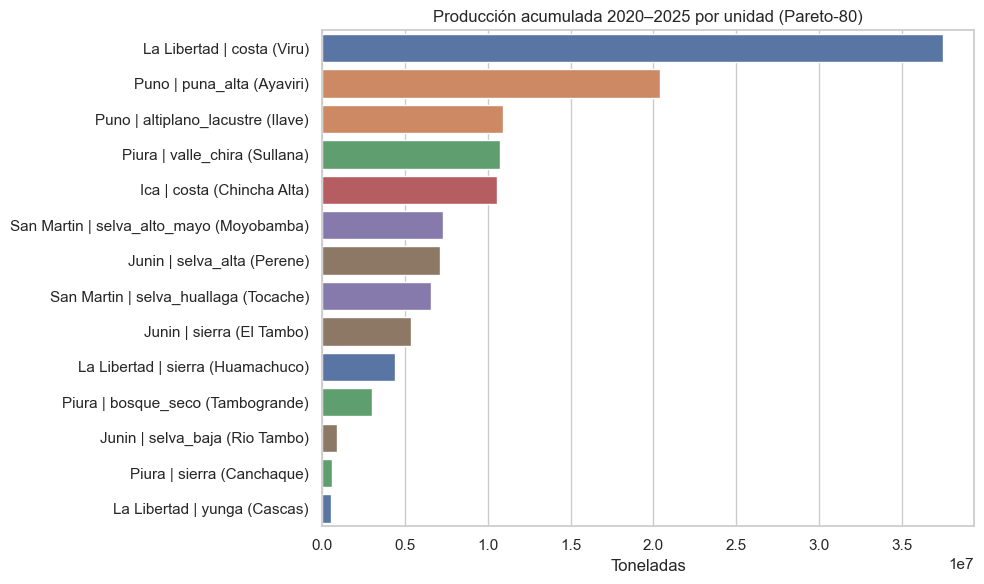

In [3]:
# =============================================================================
# CELDA 2 — §1 Volumen productivo acumulado por unidad territorial
# =============================================================================
# Propósito:
#   Cuantificar la producción total 2020–2025 por unidad Pareto-80 y su peso
#   relativo (% del total nacional del subconjunto) para priorizar territorios.
# Sección del análisis: Análisis A — §1 Concentración productiva (Pareto).
# Salidas esperadas:
#   - Consola: top 5 unidades por toneladas y porcentaje.
#   - Figura: OUTPUTS/figures/eda_regional_volumen_unidad.png
# =============================================================================

# Suma de produccion_piso_ton por unidad; min_count=1 evita sumar filas 100% NaN
vol_unidad = (
    df.groupby(["region", "piso_ecologico", "distrito", "unidad"], observed=True)["produccion_piso_ton"]
    .sum(min_count=1)
    .reset_index(name="produccion_total_ton")
    .sort_values("produccion_total_ton", ascending=False)
)
# Participación porcentual de cada unidad respecto al total agregado
vol_unidad["pct_total"] = 100 * vol_unidad["produccion_total_ton"] / vol_unidad["produccion_total_ton"].sum()

print("=== Top 5 unidades por volumen ===")
print(vol_unidad.head(5)[["unidad", "produccion_total_ton", "pct_total"]].to_string(index=False))

# Barras horizontales: una barra por unidad, color implícito por región (hue)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=vol_unidad, y="unidad", x="produccion_total_ton",
    hue="region", dodge=False, legend=False, ax=ax,
)
ax.set_title("Producción acumulada 2020–2025 por unidad (Pareto-80)")
ax.set_xlabel("Toneladas")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_volumen_unidad.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Series temporales de producción

Agregación anual y mensual; líneas por unidad territorial.

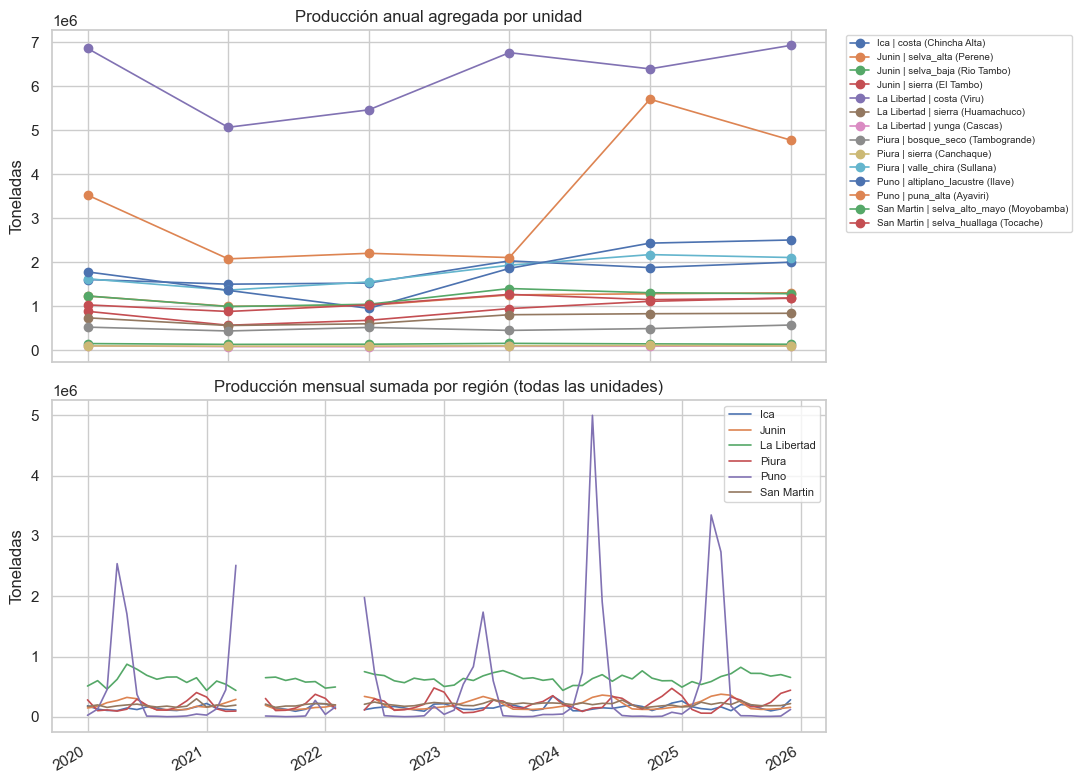

In [4]:
# =============================================================================
# CELDA 3 — §2 Series temporales de producción (anual y mensual)
# =============================================================================
# Propósito:
#   Visualizar la evolución interanual por unidad territorial y la suma mensual
#   por región para detectar tendencias, quiebres y estacionalidad agregada.
# Sección del análisis: Análisis A — §2 Dinámica temporal.
# Salidas esperadas:
#   - Figura con dos subplots: OUTPUTS/figures/eda_regional_produccion_anual.png
#     (arriba: líneas anuales por unidad; abajo: mensual por región)
# =============================================================================

# Panel anual: una fila por (unidad, año) con producción sumada en el año
prod_anual = (
    df.groupby(["region", "piso_ecologico", "distrito", "unidad", "anio"], observed=True)["produccion_piso_ton"]
    .sum(min_count=1)
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

# Subplot superior: tendencia anual de cada unidad Pareto
for unidad, g in prod_anual.groupby("unidad"):
    axes[0].plot(g["anio"], g["produccion_piso_ton"], marker="o", label=unidad, linewidth=1.2)
axes[0].set_title("Producción anual agregada por unidad")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Toneladas")
axes[0].legend(bbox_to_anchor=(1.02, 1), fontsize=7, ncol=1)

# Subplot inferior: suma mensual de todas las unidades dentro de cada región
for region, g in df.groupby("region"):
    m = g.groupby("fecha", observed=True)["produccion_piso_ton"].sum(min_count=1)
    axes[1].plot(m.index, m.values, label=region, linewidth=1.2)
axes[1].set_title("Producción mensual sumada por región (todas las unidades)")
axes[1].set_ylabel("Toneladas")
axes[1].legend(fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_produccion_anual.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Estacionalidad (mes × año)

Heatmaps por región: intensidad de cosecha mensual a lo largo del periodo.

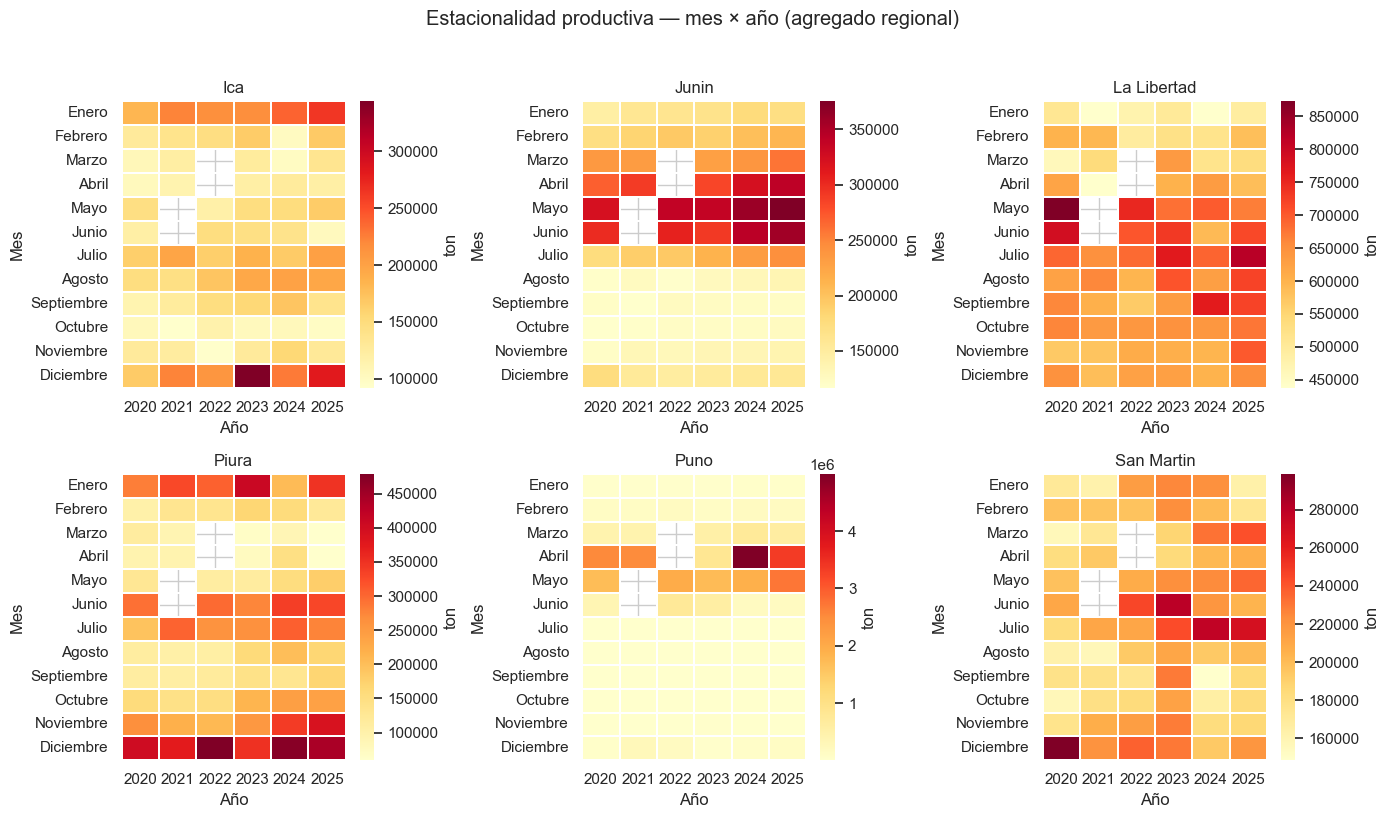

In [5]:
# =============================================================================
# CELDA 4 — §3 Heatmaps de estacionalidad mes × año por región
# =============================================================================
# Propósito:
#   Mostrar en cada región cómo se distribuye la producción entre meses y años,
#   resaltando picos de cosecha y años atípicos (sequía, Niño, etc.).
# Sección del análisis: Análisis A — §3 Estacionalidad regional.
# Salidas esperadas:
#   - Figura 2×3 (una por región): OUTPUTS/figures/eda_regional_heatmap_estacionalidad.png
# =============================================================================

regiones = sorted(df["region"].unique())
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, region in zip(axes, regiones):
    sub = df[df["region"] == region]
    # Matriz mes (fila) × año (columna) con suma de toneladas
    pivot = sub.pivot_table(
        index="mes", columns="anio", values="produccion_piso_ton",
        aggfunc=lambda x: x.sum(min_count=1), observed=True,
    )
    # Reordenar filas según MESES_ORDEN definido en el setup
    pivot = pivot.reindex(MESES_ORDEN)
    sns.heatmap(pivot, ax=ax, cmap="YlOrRd", cbar_kws={"label": "ton"}, linewidths=0.2)
    ax.set_title(region)
    ax.set_xlabel("Año")
    ax.set_ylabel("Mes")

fig.suptitle("Estacionalidad productiva — mes × año (agregado regional)", y=1.02)
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_heatmap_estacionalidad.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Patrón estacional promedio

Promedio mensual de producción (todos los años) por unidad.

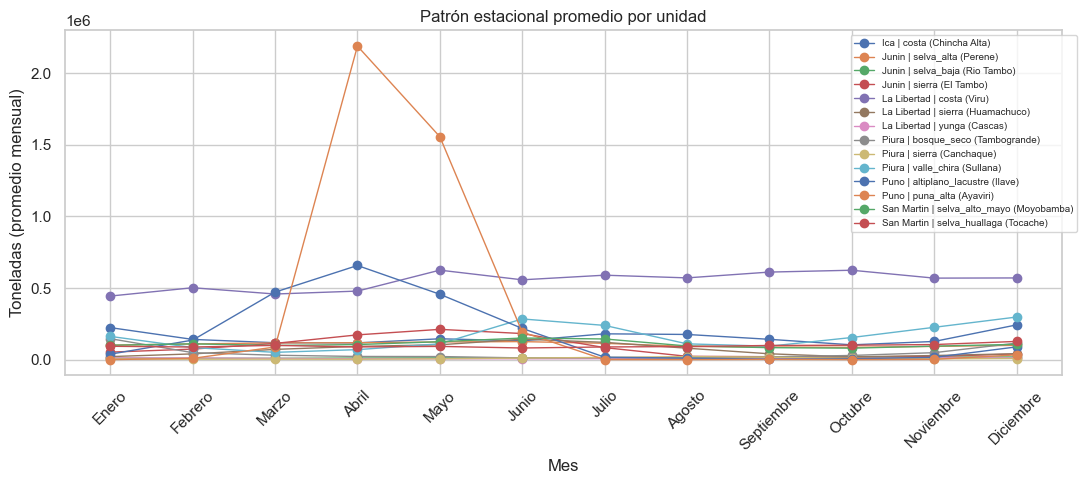

In [6]:
# =============================================================================
# CELDA 5 — §4 Patrón estacional promedio (curva mes a mes por unidad)
# =============================================================================
# Propósito:
#   Promediar la producción de cada mes del calendario por unidad para ver el
#   ciclo típico de cosecha independiente del año (perfil fenológico agregado).
# Sección del análisis: Análisis A — §4 Ciclo estacional medio.
# Salidas esperadas:
#   - Figura de líneas: OUTPUTS/figures/eda_regional_patron_estacional.png
# =============================================================================

# Media mensual histórica por unidad (todos los años del panel)
patron = (
    df.groupby(["unidad", "mes"], observed=True)["produccion_piso_ton"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for unidad, g in patron.groupby("unidad"):
    g = g.sort_values("mes")
    ax.plot(g["mes"].astype(str), g["produccion_piso_ton"], marker="o", label=unidad, linewidth=1)
ax.set_title("Patrón estacional promedio por unidad")
ax.set_xlabel("Mes")
ax.set_ylabel("Toneladas (promedio mensual)")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), fontsize=7)
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_patron_estacional.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Perfil climático por piso

Medias 2020–2025 de variables climáticas core por unidad (descriptivo).

C:\Users\USER\AppData\Local\Temp\ipykernel_18180\3441395703.py:16: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


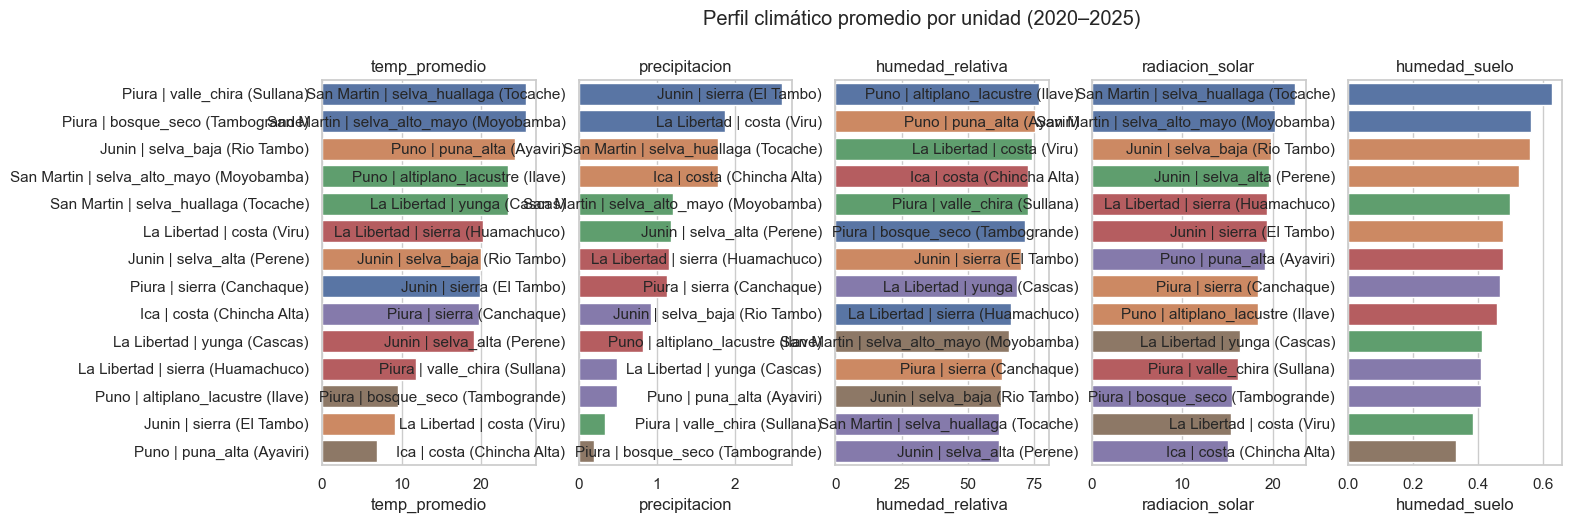

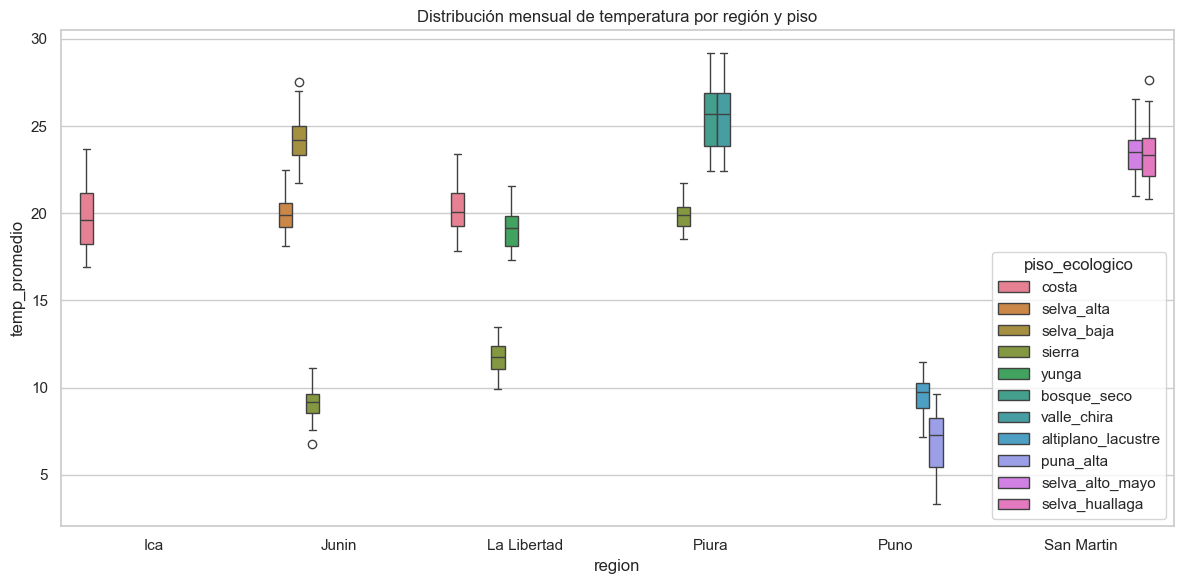

In [7]:
# =============================================================================
# CELDA 6 — §5 Perfil climático promedio por unidad y boxplot de temperatura
# =============================================================================
# Propósito:
#   Comparar el clima medio 2020–2025 entre unidades Pareto (barras por variable)
#   y la dispersión mensual de temperatura por región y piso ecológico.
# Sección del análisis: Análisis A — §5 Contexto agroclimático.
# Salidas esperadas:
#   - OUTPUTS/figures/eda_regional_perfil_climatico.png (5 paneles CLIMA_EDA)
#   - OUTPUTS/figures/eda_regional_boxplot_temp.png (distribución temp_promedio)
# =============================================================================

# Promedio multianual de cada variable en CLIMA_EDA por unidad territorial
clima_mean = (
    df.groupby(["unidad", "region"], observed=True)[CLIMA_EDA]
    .mean()
    .reset_index()
)

# Panel de barras horizontales: una subfigura por variable climática
fig, axes = plt.subplots(1, len(CLIMA_EDA), figsize=(16, 5))
for ax, var in zip(axes, CLIMA_EDA):
    sns.barplot(
        data=clima_mean.sort_values(var, ascending=False),
        x=var, y="unidad", hue="region", dodge=False, ax=ax, legend=False,
    )
    ax.set_title(var)
    ax.set_ylabel("")
fig.suptitle("Perfil climático promedio por unidad (2020–2025)", y=1.02)
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_perfil_climatico.png", dpi=150, bbox_inches="tight")
plt.show()

# Boxplot: variabilidad intra-anual de temperatura según región y piso
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="region", y="temp_promedio", hue="piso_ecologico", ax=ax)
ax.set_title("Distribución mensual de temperatura por región y piso")
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_boxplot_temp.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Correlaciones exploratorias (Pearson)

Asociación mensual clima–producción **por unidad**. Sin corrección por comparaciones múltiples.

In [8]:
# =============================================================================
# CELDA 7 — §6 Correlaciones de Pearson producción–clima por unidad
# =============================================================================
# Propósito:
#   Estimar asociación lineal exploratoria entre produccion_piso_ton y cada
#   variable de CLIMA_EDA dentro de cada unidad (≥12 meses válidos). Incluye
#   ranking top-5 y correlación pooled sobre todas las unidades juntas.
# Sección del análisis: Análisis A — §6 Correlaciones (sin corrección BH).
# Salidas esperadas:
#   - CSV: OUTPUTS/eda_correlaciones_regional.csv
#   - Consola: top 5 |r| por unidad y tabla agregada pooled
# =============================================================================

rows = []
# Una correlación por (unidad, variable_clima) con metadatos territoriales
for unidad, g in df.groupby("unidad"):
    sub = g.dropna(subset=["produccion_piso_ton"] + CLIMA_EDA)
    if len(sub) < 12:
        continue
    region = g["region"].iloc[0]
    piso = g["piso_ecologico"].iloc[0]
    distrito = g["distrito"].iloc[0]
    for var in CLIMA_EDA:
        r, p = stats.pearsonr(sub["produccion_piso_ton"], sub[var])
        rows.append({
            "unidad": unidad, "region": region, "piso_ecologico": piso,
            "distrito": distrito, "variable_clima": var,
            "n": len(sub), "r": r, "p_valor": p,
        })

corr_regional = pd.DataFrame(rows)
corr_regional.to_csv(RUTA_OUTPUT / "eda_correlaciones_regional.csv", index=False, encoding="utf-8-sig")

top5 = corr_regional.reindex(corr_regional["r"].abs().sort_values(ascending=False).index).head(5)
print("=== Top 5 |r| por unidad (exploratorio, sin BH) ===")
print(top5[["unidad", "variable_clima", "n", "r", "p_valor"]].to_string(index=False))

# Pooling: mezcla todas las unidades — sesgo por heterogeneidad territorial
sub_all = df.dropna(subset=["produccion_piso_ton"] + CLIMA_EDA)
print("\n=== Correlación agregada (pooling de todas las unidades) ===")
for var in CLIMA_EDA:
    r, p = stats.pearsonr(sub_all["produccion_piso_ton"], sub_all[var])
    print(f"{var:20s} r={r:+.3f}  p={p:.2e}  n={len(sub_all)}")


=== Top 5 |r| por unidad (exploratorio, sin BH) ===
                           unidad   variable_clima  n         r      p_valor
Puno | altiplano_lacustre (Ilave)    humedad_suelo 68  0.662909 7.337776e-10
       Piura | sierra (Canchaque) humedad_relativa 68 -0.583163 1.804417e-07
      Junin | selva_alta (Perene)    temp_promedio 68 -0.564705 5.273619e-07
        Junin | sierra (El Tambo)    humedad_suelo 68  0.553206 9.960189e-07
        Junin | sierra (El Tambo) humedad_relativa 68  0.497735 1.570431e-05

=== Correlación agregada (pooling de todas las unidades) ===
temp_promedio        r=-0.107  p=9.79e-04  n=952
precipitacion        r=-0.098  p=2.44e-03  n=952
humedad_relativa     r=+0.144  p=8.44e-06  n=952
radiacion_solar      r=+0.120  p=2.15e-04  n=952
humedad_suelo        r=-0.057  p=8.06e-02  n=952


## 7. Caso sequía — Puno 2021→2022

Co-movimiento descriptivo entre producción agregada y humedad de suelo en altiplano (no atribución causal).

=== Cambio producción Puno 2021→2022 ===
                           unidad  pct_cambio_2021_2022
Puno | altiplano_lacustre (Ilave)                 -30.0
       Puno | puna_alta (Ayaviri)                   6.1


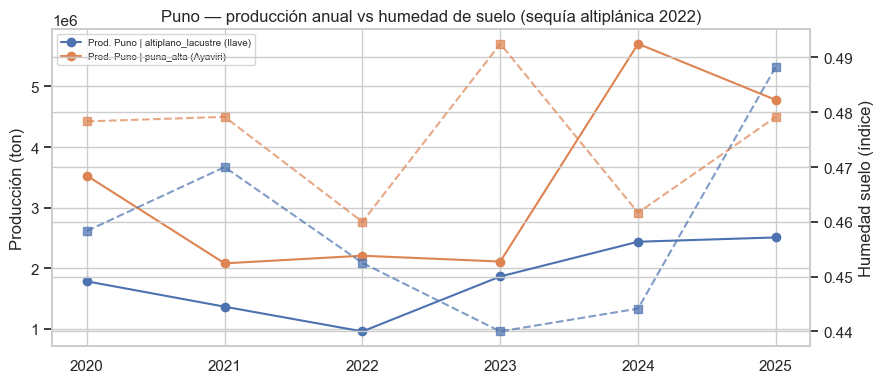

In [9]:
# =============================================================================
# CELDA 8 — §7 Caso de estudio: sequía altiplánica en Puno (2021→2022)
# =============================================================================
# Propósito:
#   Documentar cuantitativamente la caída productiva entre 2021 y 2022 en Puno
#   y contrastarla con la evolución de humedad de suelo (proxy de estrés hídrico).
# Sección del análisis: Análisis A — §7 Caso sequía (evidencia para el informe).
# Salidas esperadas:
#   - Consola: tabla de % cambio 2021→2022 por unidad (si hay datos).
#   - Figura dual-eje: OUTPUTS/figures/eda_regional_puno_sequia.png
# =============================================================================

puno = df[df["region"] == "Puno"].copy()

prod_puno = (
    puno.groupby(["unidad", "anio"], observed=True)["produccion_piso_ton"]
    .sum(min_count=1)
    .reset_index()
)
clima_puno = (
    puno.groupby(["unidad", "anio"], observed=True)["humedad_suelo"]
    .mean()
    .reset_index()
)

# Variación porcentual interanual por unidad (solo si hay producción positiva en 2021)
cambios = []
for unidad in prod_puno["unidad"].unique():
    p21 = prod_puno.query("unidad == @unidad and anio == 2021")["produccion_piso_ton"]
    p22 = prod_puno.query("unidad == @unidad and anio == 2022")["produccion_piso_ton"]
    if len(p21) and len(p22) and p21.iloc[0] > 0:
        pct = 100 * (p22.iloc[0] - p21.iloc[0]) / p21.iloc[0]
        cambios.append({"unidad": unidad, "pct_cambio_2021_2022": round(pct, 1)})
if cambios:
    print("=== Cambio producción Puno 2021→2022 ===")
    print(pd.DataFrame(cambios).to_string(index=False))

# Eje izquierdo: producción anual; eje derecho: humedad de suelo media anual
fig, ax1 = plt.subplots(figsize=(9, 4))
for unidad, g in prod_puno.groupby("unidad"):
    ax1.plot(g["anio"], g["produccion_piso_ton"], marker="o", label=f"Prod. {unidad}")
ax1.set_ylabel("Producción (ton)")
ax1.set_title("Puno — producción anual vs humedad de suelo (sequía altiplánica 2022)")
ax1.legend(fontsize=7, loc="upper left")

ax2 = ax1.twinx()
for unidad, g in clima_puno.groupby("unidad"):
    ax2.plot(g["anio"], g["humedad_suelo"], marker="s", linestyle="--", alpha=0.7, label=f"HS {unidad}")
ax2.set_ylabel("Humedad suelo (índice)")
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_puno_sequia.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Caso El Niño costero 2023–2024

Anomalías de precipitación y temperatura en Piura, La Libertad e Ica respecto al promedio 2020–2022.

=== Referencia 2020–2022 vs evento 2023–2024 (costa norte-centro) ===

Piura — ref precip=0.391  temp=23.24
      precipitacion  temp_promedio
anio                              
2023          1.221         24.514
2024          0.507         24.192

La Libertad — ref precip=0.770  temp=16.69
      precipitacion  temp_promedio
anio                              
2023          1.170         17.538
2024          0.596         17.757

Ica — ref precip=0.124  temp=19.28
      precipitacion  temp_promedio
anio                              
2023          0.144         20.813
2024          0.163         20.246


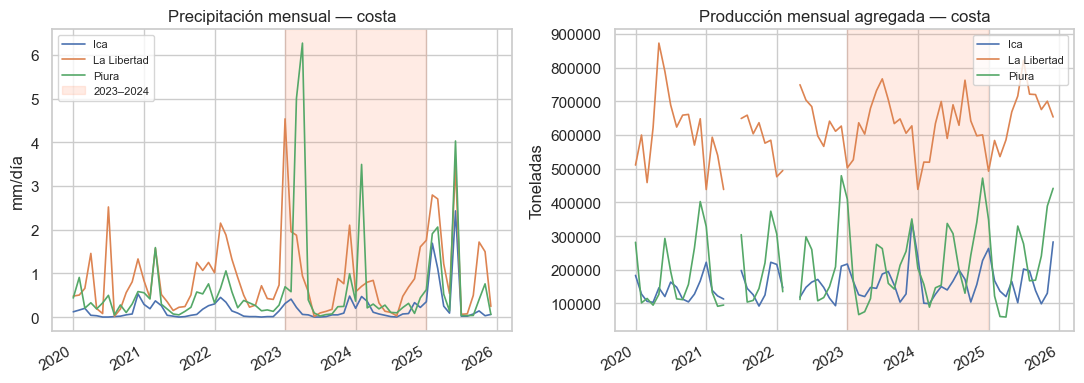

In [10]:
# =============================================================================
# CELDA 9 — §8 Caso de estudio: El Niño costero 2023–2024 (Piura, La Libertad, Ica)
# =============================================================================
# Propósito:
#   Comparar clima y producción de la costa norte-centro entre el periodo base
#   2020–2022 y el evento 2023–2024; visualizar series mensuales con sombreado.
# Sección del análisis: Análisis A — §8 Caso Niño costero.
# Salidas esperadas:
#   - Consola: precipitación y temperatura de referencia vs años del evento.
#   - Figura: OUTPUTS/figures/eda_regional_nino_costa.png (precip + producción)
# =============================================================================

costa = df[df["region"].isin(["Piura", "La Libertad", "Ica"])].copy()
ref = costa[costa["anio"].between(2020, 2022)].groupby("region")[["precipitacion", "temp_promedio"]].mean()
evt = costa[costa["anio"].isin([2023, 2024])].groupby(["region", "anio"])[["precipitacion", "temp_promedio"]].mean()

print("=== Referencia 2020–2022 vs evento 2023–2024 (costa norte-centro) ===")
for region in ["Piura", "La Libertad", "Ica"]:
    if region not in ref.index:
        continue
    ref_p = ref.loc[region, "precipitacion"]
    ref_t = ref.loc[region, "temp_promedio"]
    print(f"\n{region} — ref precip={ref_p:.3f}  temp={ref_t:.2f}")
    if region in evt.index.get_level_values(0):
        print(evt.loc[region].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel izquierdo: precipitación mensual media por región costera
for region, g in costa.groupby("region"):
    m = g.groupby("fecha", observed=True)["precipitacion"].mean()
    axes[0].plot(m.index, m.values, label=region, linewidth=1.2)
axes[0].axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2024-12-31"), alpha=0.15, color="coral", label="2023–2024")
axes[0].set_title("Precipitación mensual — costa")
axes[0].set_ylabel("mm/día")
axes[0].legend(fontsize=8)

# Panel derecho: producción mensual agregada en las mismas regiones
for region, g in costa.groupby("region"):
    m = g.groupby("fecha", observed=True)["produccion_piso_ton"].sum(min_count=1)
    axes[1].plot(m.index, m.values, label=region, linewidth=1.2)
axes[1].axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2024-12-31"), alpha=0.15, color="coral")
axes[1].set_title("Producción mensual agregada — costa")
axes[1].set_ylabel("Toneladas")
axes[1].legend(fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(RUTA_FIGURES / "eda_regional_nino_costa.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Auditoría de calidad y cierre

- NaN en producción: meses sin cosecha reportada (política del pipeline, no imputados).
- **Siguiente paso:** `05_eda_por_cultivo.ipynb` desagrega por cultivo; `06_clustering_cultivos.ipynb` construye tipologías sobre perfiles Pareto-80.

In [11]:
# =============================================================================
# CELDA 10 — §9 Auditoría de valores faltantes y resumen ejecutivo del Análisis A
# =============================================================================
# Propósito:
#   Contabilizar NaN en columnas climáticas y de producción; imprimir métricas
#   globales del panel y el número de figuras eda_regional_*.png generadas.
# Sección del análisis: Análisis A — §9 Cierre y trazabilidad de calidad.
# Salidas esperadas:
#   - Consola: conteo de NaN por columna (si los hay) y diccionario resumen.
#   - No genera archivos adicionales.
# =============================================================================

# Todas las columnas de temperatura más el núcleo de variables hidrometeorológicas
clima_cols = [c for c in df.columns if c.startswith("temp_") or c in (
    "precipitacion", "humedad_relativa", "radiacion_solar", "humedad_suelo",
)]
nan_audit = df[clima_cols + ["produccion_piso_ton"]].isna().sum()
print("=== Auditoría NaN ===")
print(nan_audit[nan_audit > 0] if (nan_audit > 0).any() else "Sin NaN en columnas revisadas")

resumen = {
    "filas": len(df),
    "unidades": df["unidad"].nunique(),
    "regiones": df["region"].nunique(),
    "nan_produccion": int(df["produccion_piso_ton"].isna().sum()),
    "figuras_generadas": len(list(RUTA_FIGURES.glob("eda_regional_*.png"))),
}
print("\n=== Resumen Análisis A ===")
for k, v in resumen.items():
    print(f"{k}: {v}")


=== Auditoría NaN ===
produccion_piso_ton    56
dtype: int64

=== Resumen Análisis A ===
filas: 1008
unidades: 14
regiones: 6
nan_produccion: 56
figuras_generadas: 8
